In [1]:
# Cell 1: Start Spark session
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import findspark
findspark.init()

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StringType
from src.utils import preprocess_text

spark = SparkSession.builder \
    .appName("Arabic-AI-Detection-Preprocessing") \
    .config("spark.driver.memory", "3g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"  Spark {spark.version}")

26/05/19 06:19:51 WARN Utils: Your hostname, localhost.localdomain resolves to a loopback address: 127.0.0.1; using 192.168.1.26 instead (on interface enp0s3)
26/05/19 06:19:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 06:19:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/19 06:19:53 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


  Spark 3.5.8


In [2]:
# Cell 2: Load combined raw Parquet
HDFS_RAW_PARQUET = "hdfs://localhost:9000/user/hadoop/arabic-ai-detection/raw_combined.parquet"
df_raw = spark.read.parquet(HDFS_RAW_PARQUET)
print(f"Raw rows: {df_raw.count()}")
df_raw.printSchema()

Raw rows: 8388
root
 |-- original_abstract: string (nullable = true)
 |-- allam_generated_abstract: string (nullable = true)
 |-- jais_generated_abstract: string (nullable = true)
 |-- llama_generated_abstract: string (nullable = true)
 |-- openai_generated_abstract: string (nullable = true)
 |-- generation_method: string (nullable = true)



In [3]:
# Cell 3: Wide → Long format


ai_models = ["allam", "jais", "llama", "openai"]

# Build the long-format DataFrame
human_df = df_raw.select(
    F.col("original_abstract").alias("text"),
    F.lit(0).alias("label"),
    F.lit("human").alias("source"),
    F.col("generation_method")
)

ai_dfs = []
for model in ai_models:
    col = f"{model}_generated_abstract"
    ai_dfs.append(
        df_raw.select(
            F.col(col).alias("text"),
            F.lit(1).alias("label"),
            F.lit(model).alias("source"),
            F.col("generation_method")
        )
    )

# Union everything
df_long = human_df
for d in ai_dfs:
    df_long = df_long.unionByName(d)

# Drop nulls and empty
df_long = df_long.filter((F.col("text").isNotNull()) & (F.length(F.col("text")) > 10))

print(f"Long format rows: {df_long.count()}")
print("\nLabel distribution:")
df_long.groupBy("label").count().show()

print("Source distribution:")
df_long.groupBy("source").count().orderBy("source").show()

Long format rows: 41940

Label distribution:


+-----+-----+
|label|count|
+-----+-----+
|    0| 8388|
|    1|33552|
+-----+-----+

Source distribution:
+------+-----+
|source|count|
+------+-----+
| allam| 8388|
| human| 8388|
|  jais| 8388|
| llama| 8388|
|openai| 8388|
+------+-----+



In [4]:
# Cell 4: Define preprocessing INLINE
import re
import pyarabic.araby as araby

ARABIC_STOPWORDS = {
    "في", "من", "إلى", "على", "عن", "حتى", "منذ", "مذ", "خلال", "بين", "أمام", "خلف", "تحت", "فوق",
    "و", "ف", "ثم", "أو", "أم", "بل", "لكن", "كما", "حيث", "إذا", "إذ", "إن", "أن", "كان",
    "هو", "هي", "هم", "هن", "أنا", "نحن", "أنت", "أنتم", "ذلك", "تلك", "هذا", "هذه", "هؤلاء",
    "ها", "هما", "أنتما", "إياك", "إياه", "إياها",
    "كذلك", "أيضا", "أيضًا", "بعض", "كل", "جميع", "بعد", "قبل", "حول", "نحو", "ضد",
    "قد", "لقد", "لا", "ما", "لم", "لن", "ليس", "غير", "سوى",
    "كانت", "يكون", "تكون", "أصبح", "صار", "ظل", "بات",
    "إذن", "لذلك", "بحيث", "لذا",
    "أولا", "ثانيا", "ثالثا", "رابعا", "خامسا",
}

def preprocess_text(text):
    if text is None:
        return ""
    # 1. Remove diacritics
    text = araby.strip_tashkeel(text)
    # 2. Normalize Arabic
    text = araby.strip_tatweel(text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    # 3. Keep only Arabic letters + whitespace
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    # 4. Remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in ARABIC_STOPWORDS]
    return " ".join(tokens)

# Register as Spark UDF
preprocess_udf = F.udf(preprocess_text, StringType())

# Apply
df_clean = df_long.withColumn("text_clean", preprocess_udf(F.col("text")))

# Sanity check
df_clean.select("source", "text", "text_clean").show(2, truncate=80, vertical=True)

[Stage 13:>                                                         (0 + 1) / 1]

-RECORD 0--------------------------------------------------------------------------------------
 source     | human                                                                            
 text       | كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات ... 
 text_clean | كثيرا ارتبطت المصادر التاريخية الاندلس خاصة منها كتب التراجم والفهرسات والبرا... 
-RECORD 1--------------------------------------------------------------------------------------
 source     | human                                                                            
 text       | يعد العامل الثقافي احد ابرز الاسباب التي يعزى لها سقوط الدولة الموحدية ، حتى ... 
 text_clean | يعد العامل الثقافي احد ابرز الاسباب التي يعزي لها سقوط الدولة الموحدية ، حتي ... 
only showing top 2 rows



In [5]:
# Cell 5: Add basic length features
df_clean = df_clean \
    .withColumn("char_count", F.length(F.col("text_clean"))) \
    .withColumn("word_count", F.size(F.split(F.col("text_clean"), r"\s+")))


df_clean = df_clean.filter(F.col("char_count") > 20)

print(f"After cleaning: {df_clean.count()} rows")
df_clean.select("source", "label", "word_count", "char_count").show(5)

26/05/19 06:20:07 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                                                                                

After cleaning: 41940 rows
+------+-----+----------+----------+
|source|label|word_count|char_count|
+------+-----+----------+----------+
| human|    0|       107|       669|
| human|    0|       122|       765|
| human|    0|       182|      1217|
| human|    0|        98|       619|
| human|    0|       117|       738|
+------+-----+----------+----------+
only showing top 5 rows



In [6]:
# Cell 6: Save processed data to HDFS as compressed Parquet 
HDFS_PROCESSED = "hdfs://localhost:9000/user/hadoop/arabic-ai-detection/processed.parquet"

df_clean.write.mode("overwrite").option("compression", "snappy").parquet(HDFS_PROCESSED)
print(f"  Saved processed data to {HDFS_PROCESSED}")

# Verify
df_check = spark.read.parquet(HDFS_PROCESSED)
print(f"\nVerification: {df_check.count()} rows")
df_check.printSchema()

  Saved processed data to hdfs://localhost:9000/user/hadoop/arabic-ai-detection/processed.parquet

Verification: 41940 rows
root
 |-- text: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- source: string (nullable = true)
 |-- generation_method: string (nullable = true)
 |-- text_clean: string (nullable = true)
 |-- char_count: integer (nullable = true)
 |-- word_count: integer (nullable = true)



In [7]:
# Cell 7: Vocabulary richness per source

from pyspark.sql.functions import explode, split, col, countDistinct, count, lit

print(" Vocabulary Richness (Type-Token Ratio)")
print("Higher TTR = more diverse vocabulary (humans tend to score higher)\n")
print(f"{'Source':<10} {'Total Words':>12} {'Unique Words':>14} {'TTR':>8}")
print("-" * 50)

for source_name in ["human", "allam", "jais", "llama", "openai"]:
    words_df = df_clean.filter(col("source") == source_name) \
                       .select(explode(split(col("text_clean"), r"\s+")).alias("word")) \
                       .filter(col("word") != "")
    
    total = words_df.count()
    unique = words_df.select(countDistinct("word")).first()[0]
    ttr = unique / total if total > 0 else 0
    print(f"{source_name:<10} {total:>12,} {unique:>14,} {ttr:>8.4f}")

 Vocabulary Richness (Type-Token Ratio)
Higher TTR = more diverse vocabulary (humans tend to score higher)

Source      Total Words   Unique Words      TTR
--------------------------------------------------


human           858,296         53,670   0.0625


allam           672,831         43,317   0.0644


jais            563,326         44,154   0.0784


llama           736,671         48,920   0.0664


[Stage 62:===================>                                      (1 + 2) / 3]

openai          996,669         56,532   0.0567


In [8]:
# Cell 8: Top frequent words in the cleaned corpus
word_freq = df_clean.select(explode(split(col("text_clean"), r"\s+")).alias("word")) \
                    .filter(col("word") != "") \
                    .groupBy("word") \
                    .count() \
                    .orderBy(col("count").desc())

print("Top 20 most frequent words across the corpus:\n")
word_freq.show(20, truncate=False)

Top 20 most frequent words across the corpus:



[Stage 68:====================================================>   (14 + 1) / 15]

+-------+-----+
|word   |count|
+-------+-----+
|علي    |99138|
|الي    |76011|
|الدراسة|42946|
|البحث  |41654|
|ان     |38475|
|التي   |32702|
|مع     |25349|
|مما    |14397|
|تحليل  |13563|
|النتايج|13486|
|تهدف   |13070|
|اهمية  |11239|
|دراسة  |11137|
|،      |11080|
|الذي   |10324|
|الضوء  |10030|
|التركيز|9769 |
|او     |9690 |
|الجزاير|9211 |
|استخدام|8918 |
+-------+-----+
only showing top 20 rows



In [9]:
# Cell 9: Bigram analysis, most common 2 word phrases
from pyspark.ml.feature import NGram, Tokenizer

tokenizer = Tokenizer(inputCol="text_clean", outputCol="tokens")
tokenized = tokenizer.transform(df_clean.filter(col("text_clean") != ""))

ngram = NGram(n=2, inputCol="tokens", outputCol="bigrams")
bigrams_df = ngram.transform(tokenized)

bigram_freq = bigrams_df.select(explode(col("bigrams")).alias("bigram")) \
                        .filter(col("bigram") != "") \
                        .groupBy("bigram") \
                        .count() \
                        .orderBy(col("count").desc())

print("Top 10 bigrams (2-word phrases):\n")
bigram_freq.show(10, truncate=False)

Top 10 bigrams (2-word phrases):



[Stage 73:=============================>                            (2 + 2) / 4]

+--------------+-----+
|bigram        |count|
+--------------+-----+
|الدراسة الي   |15593|
|البحث الي     |10544|
|الضوء علي     |9870 |
|تهدف الدراسة  |9363 |
|التركيز علي   |9229 |
|مع التركيز    |8356 |
|الي ان        |8252 |
|يهدف البحث    |7063 |
|الورقة البحثية|5127 |
|بالاضافة الي  |4764 |
+--------------+-----+
only showing top 10 rows



Using font: /usr/share/fonts/google-noto/NotoSansArabic-Regular.ttf


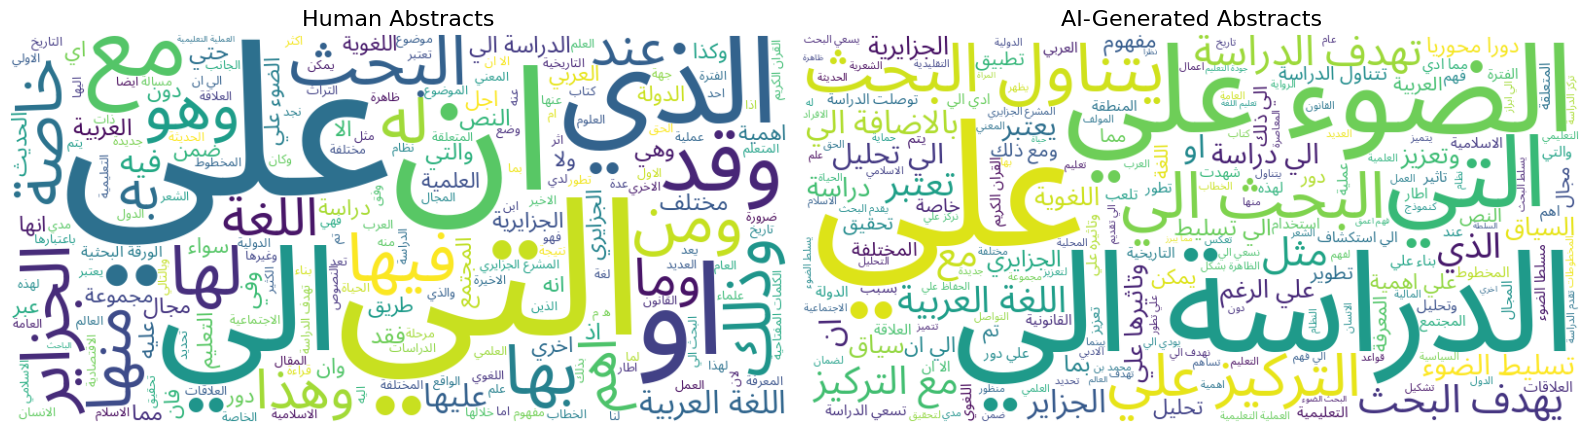

  Saved wordcloud to reports/figures/wordcloud_human_vs_ai.png


In [10]:
# Cell 10: Word cloud for human vs AI text
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os


human_text = " ".join(
    [row.text_clean for row in df_clean.filter(col("source") == "human").limit(1000).collect()]
)
ai_text = " ".join(
    [row.text_clean for row in df_clean.filter(col("source") != "human").limit(1000).collect()]
)


ARABIC_FONTS = [
    "/usr/share/fonts/google-noto-sans-arabic-vf-fonts/NotoSansArabic-VF.ttf",
    "/usr/share/fonts/dejavu/DejaVuSans.ttf",
    "/usr/share/fonts/google-noto/NotoSansArabic-Regular.ttf",
]
arabic_font = None
for f in ARABIC_FONTS:
    if os.path.exists(f):
        arabic_font = f
        break
print(f"Using font: {arabic_font or 'default (Arabic may not render correctly)'}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc1 = WordCloud(width=800, height=400, background_color="white", font_path=arabic_font).generate(human_text)
axes[0].imshow(wc1, interpolation="bilinear")
axes[0].set_title("Human Abstracts", fontsize=16)
axes[0].axis("off")

wc2 = WordCloud(width=800, height=400, background_color="white", font_path=arabic_font).generate(ai_text)
axes[1].imshow(wc2, interpolation="bilinear")
axes[1].set_title("AI-Generated Abstracts", fontsize=16)
axes[1].axis("off")

plt.tight_layout()


os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/wordcloud_human_vs_ai.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved wordcloud to reports/figures/wordcloud_human_vs_ai.png")

In [11]:
# Cell 11: Export aggregate stats
import pandas as pd

stats_rows = []
for source_name in ["human", "allam", "jais", "llama", "openai"]:
    words_df = df_clean.filter(col("source") == source_name) \
                       .select(explode(split(col("text_clean"), r"\s+")).alias("word")) \
                       .filter(col("word") != "")
    total = words_df.count()
    unique = words_df.select(countDistinct("word")).first()[0]
    avg_wc = df_clean.filter(col("source") == source_name).agg({"word_count": "avg"}).first()[0]
    stats_rows.append({
        "source": source_name,
        "total_words": total,
        "unique_words": unique,
        "ttr": unique / total if total > 0 else 0,
        "avg_words_per_abstract": avg_wc
    })

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv("../reports/figures/vocabulary_stats.csv", index=False)
print("  Saved stats to reports/figures/vocabulary_stats.csv\n")
print(stats_df.to_string(index=False))

[Stage 133:>                                                        (0 + 3) / 3]

  Saved stats to reports/figures/vocabulary_stats.csv

source  total_words  unique_words      ttr  avg_words_per_abstract
 human       858296         53670 0.062531              102.324273
 allam       672831         43317 0.064380               80.213519
  jais       563326         44154 0.078381               67.158560
 llama       736671         48920 0.066407               87.824392
openai       996669         56532 0.056721              118.820815


In [12]:
# Cell 12: Export cleaned text as CSV for MapReduce input
HDFS_MR_INPUT = "hdfs://localhost:9000/user/hadoop/arabic-ai-detection/mr_input"

df_clean.select("source", "label", "generation_method", "char_count", "text_clean") \
    .coalesce(1) \
    .write.mode("overwrite") \
    .option("header", "true") \
    .csv(HDFS_MR_INPUT)

print(f"  CSV ready for MapReduce at {HDFS_MR_INPUT}")

[Stage 136:>                                                        (0 + 1) / 1]

  CSV ready for MapReduce at hdfs://localhost:9000/user/hadoop/arabic-ai-detection/mr_input
